In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import pandas as pd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
fit_log_dir = lambda : f'logs/{datetime.now()}/fit'
WINDOW_LENGTH = 24
DATA_DIR = "drive/MyDrive/"

In [ ]:
def df_to_x_y(df, window=5):
  vals = df.values
  x = []
  y = []
  for i in range(len(vals) -  window):
    row = vals[i:i+window]
    x.append(row)
    y.append(vals[i+window])
  return np.array(x), np.array(y)

In [ ]:
chid_df = pd.read_csv(DATA_DIR +"chid-01-23.csv").dropna()
chid_df['time'] = pd.to_datetime(chid_df['time'])
chid_df = chid_df.set_index('time')
chid_df.head()

,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),rain (mm),weather_code (wmo code),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_speed_100m (km/h),wind_direction_10m (°),wind_direction_100m (°),wind_gusts_10m (km/h)
time,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00,24.4,70.0,18.5,24.6,0.0,0.0,1.0,1012.4,1011.6,22.0,21.0,6.0,0.0,0.08,0.93,19.9,27.5,46.0,47.0,29.9
2000-01-01 01:00:00,24.0,71.0,18.4,24.4,0.0,0.0,1.0,1011.8,1011.0,23.0,26.0,0.0,0.0,0.07,0.87,18.8,26.2,47.0,47.0,28.4
2000-01-01 02:00:00,23.7,72.0,18.3,24.1,0.0,0.0,1.0,1011.2,1010.4,29.0,32.0,0.0,0.0,0.07,0.83,18.3,25.5,45.0,45.0,27.4
2000-01-01 03:00:00,23.4,73.0,18.3,24.3,0.0,0.0,1.0,1010.9,1010.1,29.0,32.0,1.0,0.0,0.05,0.77,14.8,20.6,43.0,43.0,26.3
2000-01-01 04:00:00,22.9,75.0,18.3,23.9,0.0,0.0,1.0,1010.6,1009.8,44.0,42.0,11.0,0.0,0.04,0.69,14.1,19.8,40.0,37.0,25.6


In [ ]:
x, y = df_to_x_y(chid_df, WINDOW_LENGTH)

In [ ]:
# Generate some dummy weather data (replace this with your actual data)
# Assume we have images representing weather patterns
# X_train, y_train, X_test, y_test = load_weather_data()

# Example dummy data
X_train = np.random.rand(100, 64, 64, 3)  # 100 images of size 64x64 with 3 channels (RGB)
y_train = np.random.randint(2, size=100)  # Binary classification (sunny or not sunny)

X_test = np.random.rand(20, 64, 64, 3)  # 20 test images
y_test = np.random.randint(2, size=20)

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
print(model)

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

Epoch 1/50
4/4 [==============================] - 2s 228ms/step - loss: 0.6899 - accuracy: 0.5500 - val_loss: 0.6481 - val_accuracy: 0.7000
Epoch 2/50
4/4 [==============================] - 1s 144ms/step - loss: 0.7192 - accuracy: 0.5300 - val_loss: 0.7131 - val_accuracy: 0.3000
Epoch 3/50
4/4 [==============================] - 1s 163ms/step - loss: 0.6919 - accuracy: 0.4700 - val_loss: 0.7794 - val_accuracy: 0.3000
Epoch 4/50
4/4 [==============================] - 1s 141ms/step - loss: 0.7164 - accuracy: 0.4700 - val_loss: 0.6933 - val_accuracy: 0.4500
Epoch 5/50
4/4 [==============================] - 1s 135ms/step - loss: 0.6837 - accuracy: 0.6400 - val_loss: 0.6289 - val_accuracy: 0.7000
Epoch 6/50
4/4 [==============================] - 1s 146ms/step - loss: 0.6996 - accuracy: 0.5300 - val_loss: 0.6447 - val_accuracy: 0.7000
Epoch 7/50
4/4 [==============================] - 1s 241ms/step - loss: 0.6837 - accuracy: 0.5300 - val_loss: 0.6571 - val_accuracy: 0.7000
Epoch 8/50
4/4 [====

In [ ]:
def zscore(series, window, thresh=3, return_all=False):
  rolling = series.rolling(window=window, min_periods=1, center=True)
  mean = rolling.mean()
  std = rolling.std(ddof=0)
  z = series.sub(mean).div(std)
  m = z.between(-thresh, thresh)

  if return_all:
    return z, mean, std, m

  return series.where(m, mean)


In [ ]:
import matplotlib.pyplot as plt

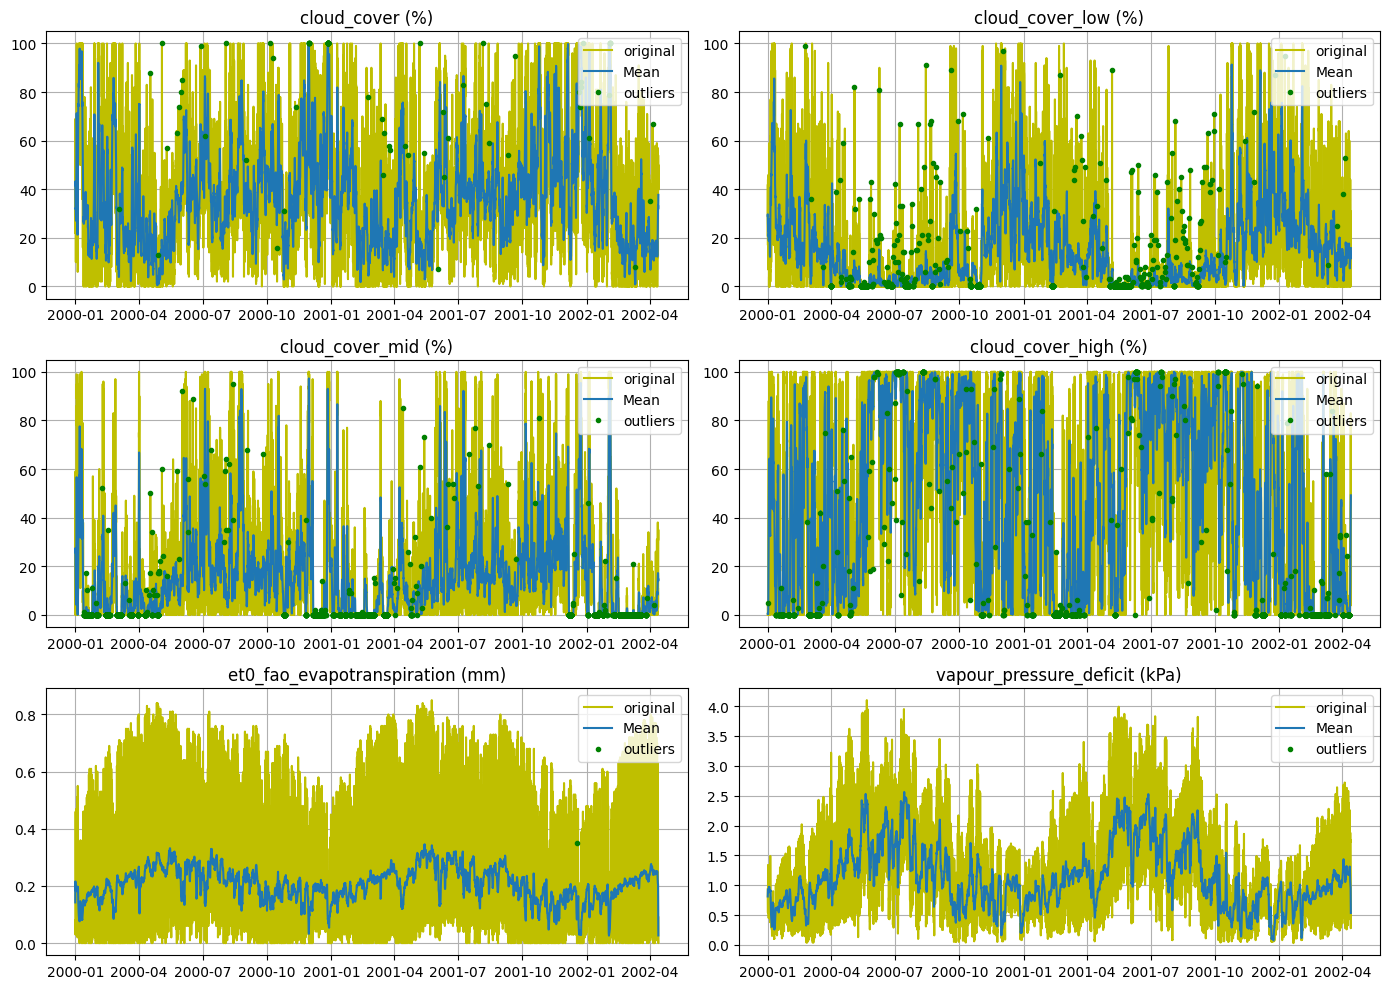

In [ ]:
plt.figure(figsize=(14, 10))
points = 20000

for i in range(6):
  plt.subplot(321+i)
  col = chid_df.columns[i+9]
  plt.title(col)
  plt.plot(chid_df[col].iloc[:points], label='original',c='y')

  z, mean, std, m = zscore(chid_df[col].iloc[:points], WINDOW_LENGTH, return_all=True)


  plt.plot(mean, label="Mean")
  # plt.plot(z + mean, label="std")

  plt.plot(chid_df[col].iloc[:points].where(~m), '.', label='outliers', c='g')

  plt.grid()
  plt.legend(loc="upper right")
plt.tight_layout()
plt.show()
